In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
from src.data_loader import DataLoader

dataLoader = DataLoader()
dataLoader.download()
dataLoader.clean()
dataLoader.add_features()
dataLoader.add_technical_indicators()
sp500 = dataLoader.data

In [3]:
import pandas as pd

sp500.index = pd.to_datetime(sp500.index)
sp500 = sp500.loc["1990-01-01":].copy()
sp500 = sp500.dropna(subset=sp500.columns[sp500.columns!="Tomorrow"])

In [4]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Volume_Ratio_2,Trend_2,...,Trend_1000,Body_Pct,Range_Pct,EMA_9,EMA_12,EMA_26,MACD,MACD_Signal,MACD_Histogram,ATR_14
Date,,,,,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,1.008821,1.052368,2.0,...,568.0,1.779855,2.143510,350.996152,350.146235,348.011372,2.134864,1.273021,0.861843,3.599282
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,1.085384,1.0,...,568.0,-0.258554,0.748768,352.548924,351.471431,348.807567,2.663864,1.551190,1.112675,3.520711
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,0.958492,0.0,...,568.0,-0.861299,1.636190,353.173142,352.117367,349.315897,2.801471,1.801246,1.000225,3.764995
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,0.944953,0.0,...,568.0,-0.975624,1.214611,352.978516,352.130082,349.529535,2.600547,1.961106,0.639441,3.882852
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,0.938320,1.0,...,568.0,0.451447,1.044484,353.140814,352.385455,349.845125,2.540330,2.076951,0.463379,3.734279
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17 00:00:00-04:00,7074.549805,7147.520020,7074.549805,7126.060059,6145300000,7109.140137,0,1.005984,1.085843,2.0,...,540.0,0.728106,1.020917,6918.568866,6869.584687,6780.442269,89.142418,23.518693,65.623726,93.707833
2026-04-20 00:00:00-04:00,7117.049805,7122.649902,7084.410156,7109.140137,4661130000,7064.009766,0,0.998811,0.862659,1.0,...,540.0,-0.111137,0.536875,6956.683120,6906.439372,6804.790259,101.649113,39.144777,62.504336,88.797119
2026-04-21 00:00:00-04:00,7122.640137,7137.270020,7050.200195,7064.009766,5160270000,7137.899902,1,0.996816,1.050822,0.0,...,539.0,-0.823155,1.219932,6978.148449,6930.680971,6823.991704,106.689267,52.653675,54.035592,81.064279


<Axes: xlabel='Date'>

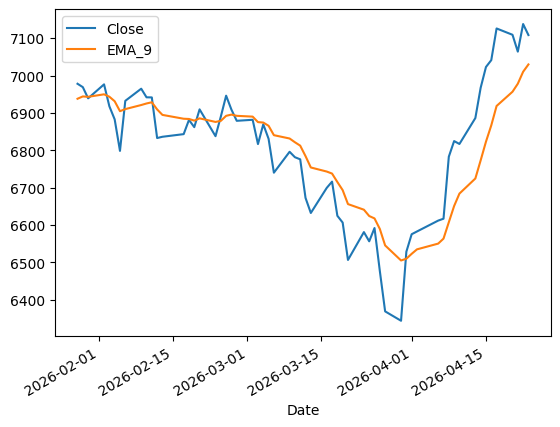

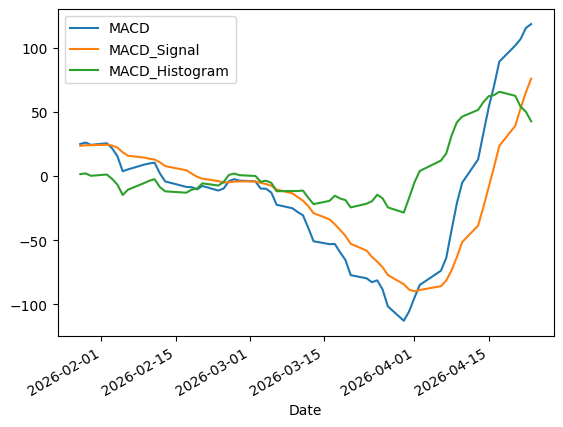

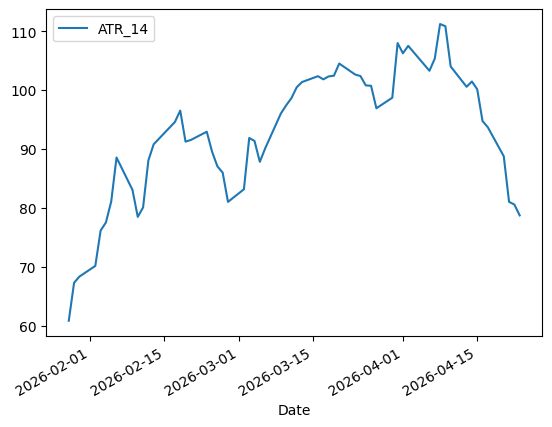

In [5]:
last_60_days = sp500.iloc[-60:]

# EMA 9
last_60_days[['Close', 'EMA_9']].plot.line(use_index=True)

# MACD 
last_60_days[['MACD', 'MACD_Signal', 'MACD_Histogram']].plot.line(use_index=True)

# ATR 14
last_60_days[['ATR_14']].plot.line(use_index=True)

In [6]:
from sklearn.ensemble import RandomForestClassifier
from src.evaluate import backtest

model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

predictors = [
    # Technical indicators
    "EMA_9", "MACD", "MACD_Signal", "MACD_Histogram", "ATR_14",

    # Price action features
    "Close_Ratio_2", "Close_Ratio_5", "Close_Ratio_60", "Close_Ratio_250", "Close_Ratio_1000",
    "Volume_Ratio_2", "Volume_Ratio_5", "Volume_Ratio_60", "Volume_Ratio_250", "Volume_Ratio_1000",
    "Trend_2", "Trend_5", "Trend_60", "Trend_250", "Trend_1000",

    "Body_Pct", "Range_Pct"
]

predictions = backtest(sp500, model, predictors)

In [7]:
predictions

,Target,Predictions
Date,,
1999-11-22 00:00:00-05:00,0,0
1999-11-23 00:00:00-05:00,1,0
1999-11-24 00:00:00-05:00,0,0
1999-11-26 00:00:00-05:00,0,0
1999-11-29 00:00:00-05:00,0,0
...,...,...
2026-04-17 00:00:00-04:00,0,0
2026-04-20 00:00:00-04:00,0,0
2026-04-21 00:00:00-04:00,1,0


In [8]:
predictions["Predictions"].value_counts()

Predictions
0    6342
1     302
Name: count, dtype: int64

In [9]:
from sklearn.metrics import precision_score

precision_score(predictions["Target"], predictions["Predictions"])

0.5794701986754967

In [10]:
from src.evaluate import add_returns, plot_equity_curve, plot_prediction_distribution, summary_metrics

predictions = add_returns(predictions, sp500)

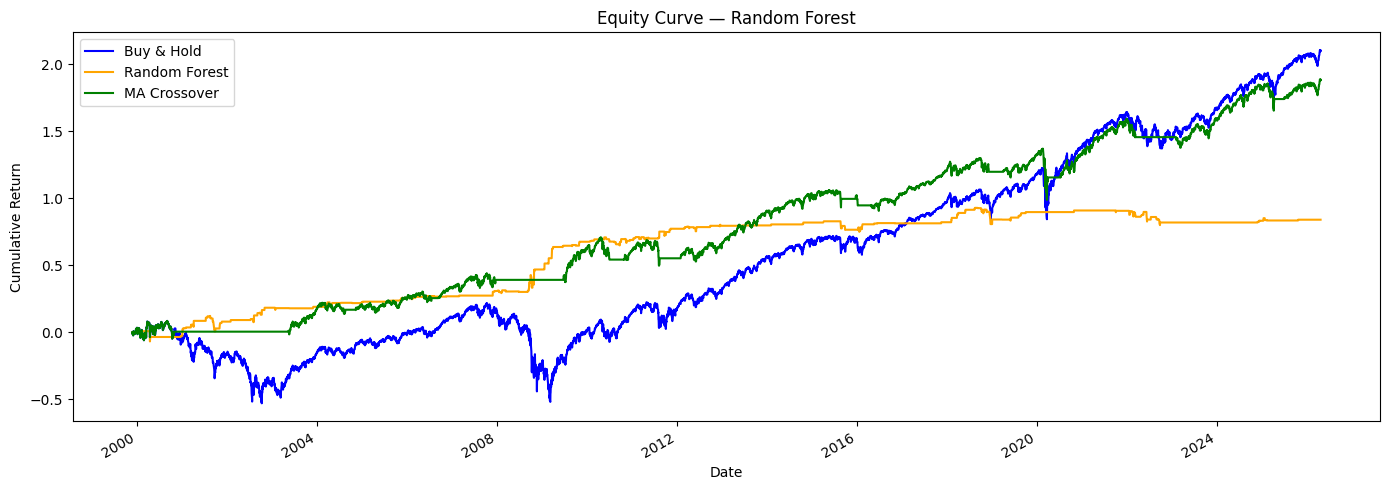

In [11]:
plot_equity_curve(predictions, "Random Forest", sp500)

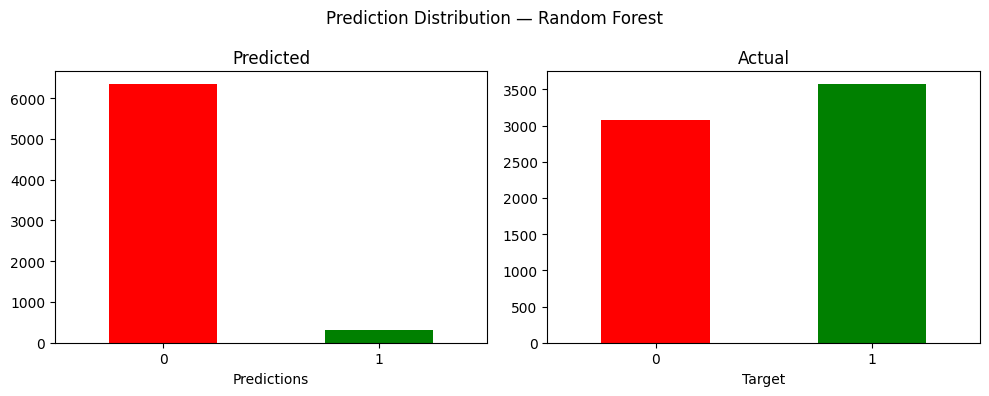

In [12]:
plot_prediction_distribution(predictions, "Random Forest")

In [13]:
summary_metrics(predictions, "Random Forest", sp500)

{'Model': 'Random Forest',
 'Precision': 0.5795,
 'Sharpe Ratio': 0.553,
 'Strategy Return': 0.8392,
 'Buy & Hold Return': 2.1006,
 'MA Crossover Return': 1.8822,
 'Number of Trades': 302}

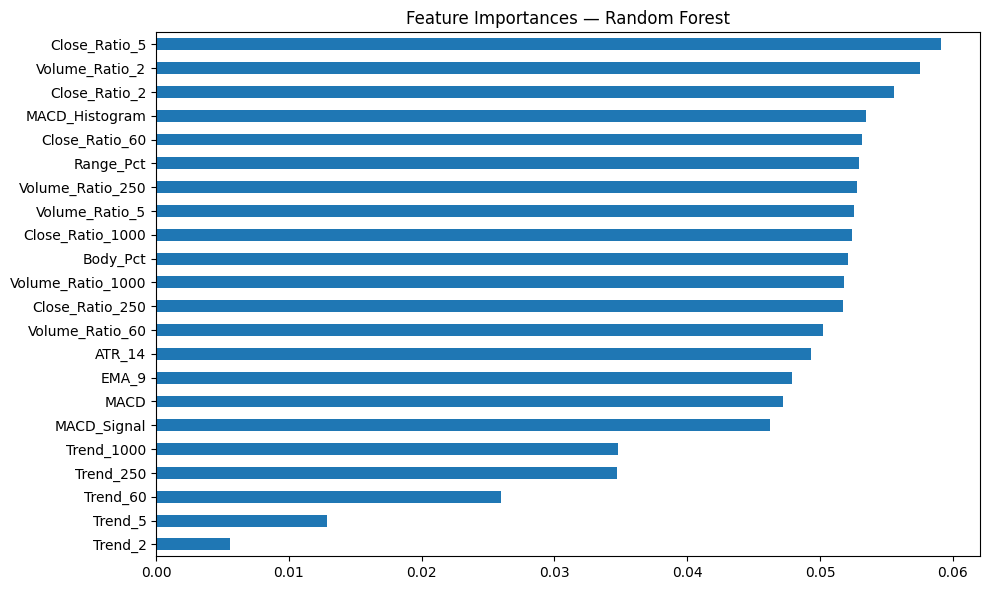

In [14]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=predictors)
importances.sort_values().plot.barh(
    figsize=(10, 6),
    title='Feature Importances — Random Forest'
)
plt.tight_layout()
plt.show()

In [15]:
import joblib

joblib.dump(predictions, '../models/predictions_random_forest.joblib')

['../models/predictions_random_forest.joblib']